# 4.5. 벽을 뚫고 나가다

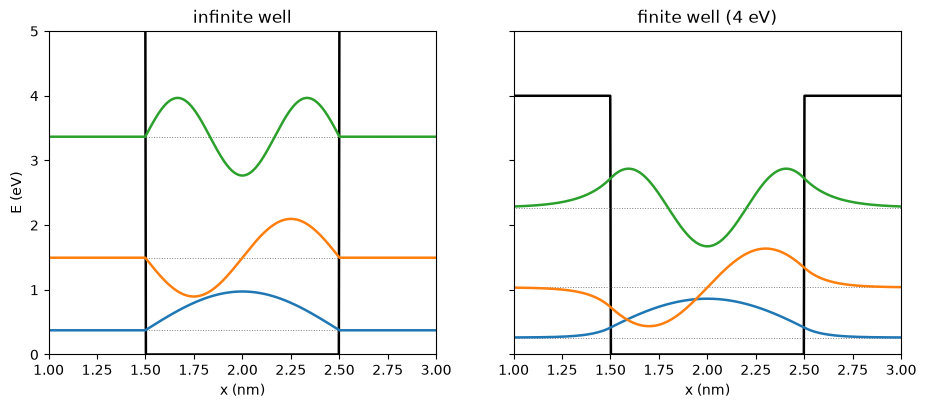

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import hbar, m_e, e, h


def second_derivative_matrix(N, dx):
    return (-2 * np.eye(N) + np.eye(N, k=1) + np.eye(N, k=-1)) / dx**2


def solve(N, L, potential):
    dx = L / (N + 1)
    x = np.linspace(0, L, N + 2)[1:-1]
    H = -(hbar**2) / (2 * m_e) * second_derivative_matrix(N, dx) + np.diag(potential(x))
    E, psi = np.linalg.eigh(H)
    return x, E / e, psi


L, N, w = 4e-9, 1200, 1e-9  # 전체 구간 4 nm, 우물 폭 1 nm


def well(V0_eV):
    """가운데 폭 w인 우물, 바깥은 V0"""
    return lambda x: np.where(np.abs(x - L / 2) < w / 2, 0.0, V0_eV * e)


fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)

for ax, (V0, title) in zip(axes, [(1e6, "infinite well"), (4.0, "finite well (4 eV)")]):
    x, E, psi = solve(N, L, well(V0))
    ax.plot(x * 1e9, np.clip(well(V0)(x) / e, 0, 6), color="black", lw=1.8)
    for k in range(3):
        v = psi[:, k]
        if v[np.argmax(np.abs(v))] < 0:
            v = -v
        ax.hlines(E[k], 0, L * 1e9, color="gray", lw=0.7, ls=":")
        ax.plot(x * 1e9, E[k] + 0.6 * v / np.abs(v).max(), lw=1.8)
    ax.set_xlim(1.0, 3.0)
    ax.set_ylim(0, 5)
    ax.set_xlabel("x (nm)")
    ax.set_title(title, fontsize=12)

axes[0].set_ylabel("E (eV)")
plt.show()

In [2]:
x, E, psi = solve(N, L, well(4.0))
outside = np.abs(x - L / 2) > w / 2

for k in range(3):
    v = psi[:, k]
    p = np.sum(v[outside] ** 2) / np.sum(v**2)
    print(f"n = {k+1}: E = {E[k]:.3f} eV,  벽 안에서 발견될 확률 = {p*100:.2f}%")

n = 1: E = 0.263 eV,  벽 안에서 발견될 확률 = 1.10%
n = 2: E = 1.038 eV,  벽 안에서 발견될 확률 = 4.80%
n = 3: E = 2.273 eV,  벽 안에서 발견될 확률 = 13.02%


In [3]:
x, E, psi = solve(N, L, well(4.0))

for n in range(1, 4):
    infinite = n**2 * h**2 / (8 * m_e * w**2) / e
    print(f"n = {n}: 무한 우물 {infinite:7.4f} eV  유한 우물 {E[n-1]:7.4f} eV")

n = 1: 무한 우물  0.3760 eV  유한 우물  0.2626 eV
n = 2: 무한 우물  1.5041 eV  유한 우물  1.0376 eV
n = 3: 무한 우물  3.3843 eV  유한 우물  2.2726 eV


In [4]:
for V0 in [1, 3, 5, 10, 20]:
    x, E, psi = solve(N, L, well(V0))
    bound = E[E < V0]
    print(f"V0 = {V0:2d} eV: 속박 준위 {len(bound)}개 - {np.round(bound, 3)}")

V0 =  1 eV: 속박 준위 2개 - [0.191 0.704]
V0 =  3 eV: 속박 준위 3개 - [0.249 0.98  2.11 ]
V0 =  5 eV: 속박 준위 4개 - [0.272 1.079 2.382 4.064]
V0 = 10 eV: 속박 준위 6개 - [0.298 1.188 2.655 4.669 7.153 9.777]
V0 = 20 eV: 속박 준위 8개 - [ 0.318  1.272  2.855  5.057  7.86  11.228 15.086 19.15 ]


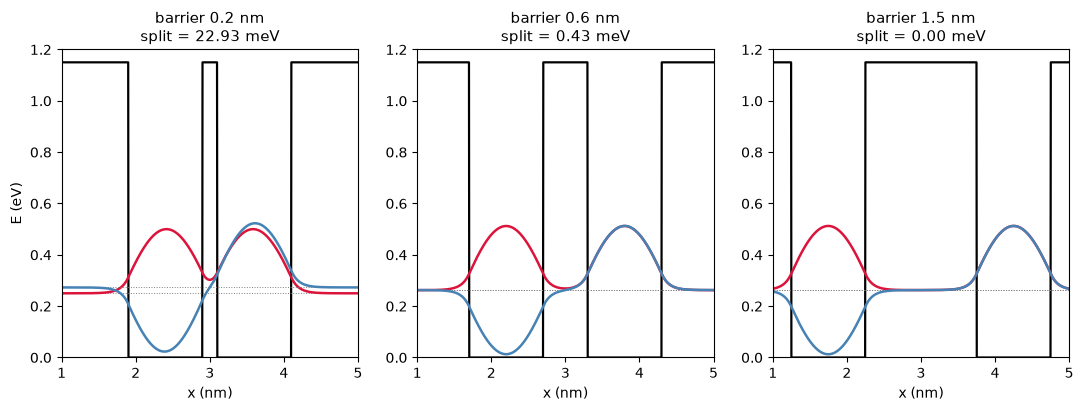

In [5]:
L2, N2, V0 = 6e-9, 1500, 4.0


def double_well(barrier_w):
    def V(x):
        out = np.full_like(x, V0 * e)
        for center in [L2 / 2 - barrier_w / 2 - w / 2, L2 / 2 + barrier_w / 2 + w / 2]:
            out[np.abs(x - center) < w / 2] = 0.0
        return out

    return V


fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, bw_nm in zip(axes, [0.2, 0.6, 1.5]):
    Vf = double_well(bw_nm * 1e-9)
    x, E, psi = solve(N2, L2, Vf)
    ax.plot(x * 1e9, np.clip(Vf(x) / e, 0, 1.15), color="black", lw=1.6)
    for k, col in zip([0, 1], ["crimson", "steelblue"]):
        v = psi[:, k]
        if v[np.argmax(np.abs(v))] < 0:
            v = -v
        ax.hlines(E[k], 0, L2 * 1e9, color="gray", lw=0.7, ls=":")
        ax.plot(x * 1e9, E[k] + 0.25 * v / np.abs(v).max(), lw=1.8, color=col)
    ax.set_xlim(1, 5)
    ax.set_ylim(0, 1.2)
    ax.set_xlabel("x (nm)")
    ax.set_title(f"barrier {bw_nm} nm\nsplit = {(E[1]-E[0])*1000:.2f} meV", fontsize=11)

axes[0].set_ylabel("E (eV)")
plt.show()

In [6]:
print(f"{'장벽(nm)':>6} {'E1(eV)':>8} {'E2(eV)':>9} {'갈라짐(meV)':>10}")
for bw_nm in [0.2, 0.4, 0.6, 0.8, 1.2]:
    x, E, psi = solve(N2, L2, double_well(bw_nm * 1e-9))
    print(f"{bw_nm:6.1f} {E[0]:9.4f} {E[1]:9.4f} {(E[1]-E[0])*1000:12.3f}")

장벽(nm)   E1(eV)    E2(eV)   갈라짐(meV)
   0.2    0.2501    0.2730       22.932
   0.4    0.2610    0.2641        3.149
   0.6    0.2623    0.2628        0.435
   0.8    0.2625    0.2626        0.060
   1.2    0.2625    0.2625        0.001


In [7]:
for bw_nm in [0.2, 0.6, 1.2]:
    x, E, psi = solve(N2, L2, double_well(bw_nm * 1e-9))
    dE = (E[1] - E[0]) * e
    print(
        f"장벽 {bw_nm} nm : 갈라짐 {dE/e*1000:7.3f} meV  ->  왕복 주기 {h/dE*1e12:10.4f} ps"
    )

장벽 0.2 nm : 갈라짐  22.932 meV  ->  왕복 주기     0.1803 ps
장벽 0.6 nm : 갈라짐   0.435 meV  ->  왕복 주기     9.5083 ps
장벽 1.2 nm : 갈라짐   0.001 meV  ->  왕복 주기  3606.2896 ps


In [8]:
nu = 23.786e9
print(f"NH3 반전: 진동수 {nu/1e9:.3f} GHz")
print(f"         준위 갈라짐 {h*nu/e*1000:.5f} meV")
print(f"         왕복 주기 {1/nu*1e12:.2f} ps")

NH3 반전: 진동수 23.786 GHz
         준위 갈라짐 0.09837 meV
         왕복 주기 42.04 ps
